In [1]:
# Анализ отмен бронирований в отеле

# Цель проекта:
# Понять, какие факторы влияют на отмену бронирований

# Бизнес-задача:
# Снижение количества отмен и увеличение загрузки отеля

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)

n = 5000

data = pd.DataFrame({
    "days_before_arrival": np.random.randint(0, 60, n),
    "price": np.random.randint(3000, 15000, n),
    "room_type": np.random.choice(["standard", "comfort", "lux"], n),
    "channel": np.random.choice(["website", "booking", "phone"], n),
    "is_refundable": np.random.choice([0, 1], n),
})

prob_cancel = (
    0.3
    + 0.3 * (data["days_before_arrival"] > 20)
    + 0.2 * (data["channel"] == "booking")
    + 0.2 * (data["is_refundable"] == 1)
)

data["is_cancelled"] = (np.random.rand(n) < prob_cancel).astype(int)

In [4]:
data.head()

,days_before_arrival,price,room_type,channel,is_refundable,is_cancelled
0,38,6220,standard,website,1,1
1,51,3539,comfort,website,0,1
2,28,4461,standard,phone,0,1
3,14,8184,comfort,booking,0,0
4,42,11547,comfort,website,0,1


In [5]:
data["is_cancelled"].value_counts(normalize=True)

is_cancelled
1    0.6738
0    0.3262
Name: proportion, dtype: float64

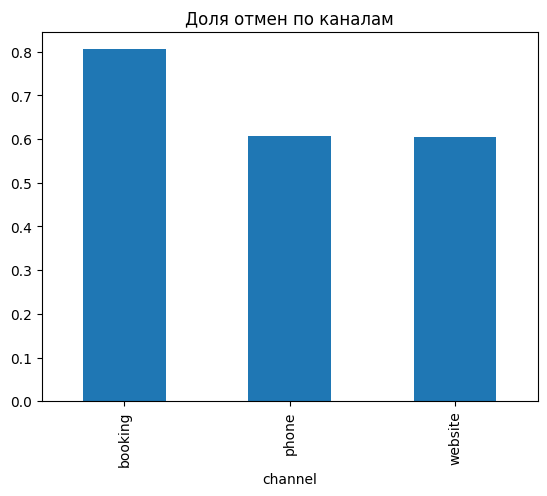

In [6]:
data.groupby("channel")["is_cancelled"].mean().plot(kind="bar")
plt.title("Доля отмен по каналам")
plt.show()

In [ ]:
/